In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,ExtraTreesClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Specify the tracking URI for the MLflow server.
mlflow.set_tracking_uri("http://localhost:5000")

# Specify the experiment you just created for your LLM application or AI agent.
mlflow.set_experiment("My Application")


In [2]:
train_path = "C:/Users/admin/Desktop/self-healing-ml/self-healing-model/data/processed/online_shoppers_intention_train.csv"
test_path = "C:/Users/admin/Desktop/self-healing-ml/self-healing-model/data/processed/online_shoppers_intention_test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

X_train = train.drop(columns=["Revenue"])
y_train = train["Revenue"]

X_test = test.drop(columns=["Revenue"])
y_test = test["Revenue"]


In [ ]:
models = {
    "RandomForest": RandomForestClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "AdaBoostClassifier":AdaBoostClassifier(),
    "xgboost":XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

logs = {}

In [ ]:
def plot_model_details(metrics: list, logs: dict):
    count = 0
    
    for metric in metrics:
        models = list(logs.keys())
        values = [v[count] for v in logs.values()]

        plt.figure()
        bars = plt.bar(models, values)

        # ✅ ADD LABELS HERE
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{height:.3f}',
                ha='center',
                va='bottom'
            )

        plt.title(f"Model {metric} Comparison")
        plt.xticks(rotation=30)
        plt.ylabel(metric)

        plt.savefig(f"{metric}.png")
        mlflow.log_artifact(f"{metric}.png")

        count += 1
        

In [ ]:
metrics = ["Accuracy", "F1 Score", "Recall","ROC AUC"]

for name, model in models.items():
    
    with mlflow.start_run(run_name=name):
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)

        # Probabilities
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test,y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        logs[name] = [acc,f1,recall,roc_auc]
        
        # Log metrics        
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("recall",recall)
        mlflow.log_metric("roc_auc", roc_auc)
        
        # Log model
        mlflow.sklearn.log_model(model, "model")

plot_model_details(metrics,logs)
mlflow.end_run()


In [ ]:
logs = {
    "lr":[0.86,0.78,0.92],
    "rf":[0.90,0.68,0.82],
    "xgb":[0.95,0.89,0.93]
}

matric = ["accuracy","f1","recall"]

In [ ]:
x = np.arange(len(matric)) # the label locations
width = 0.25 # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(10, 6)) # Adjust figure size for clarity

for attribute, measurement in logs.items():
    # Calculate the offset for each set of bars
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3) # Add labels on top of bars
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Test Subject Scores by Student')
ax.set_xticks(x + width, matric) # Position x-ticks in the center of the grouped bars
ax.legend(loc='upper left', ncols=len(logs))
ax.set_ylim(0, 1) # Assuming max score is 100

plt.show()

Text(0.5, 1.0, 'Confusion Matrix - Logistic')

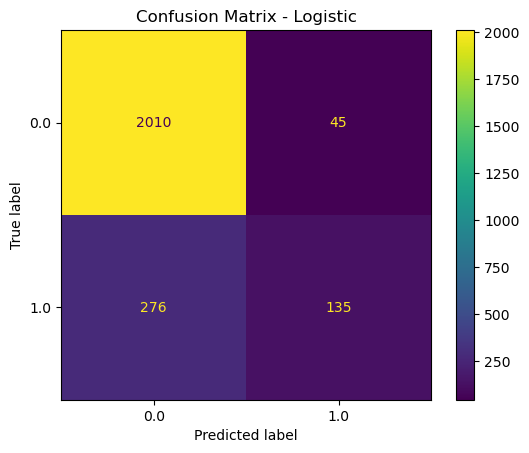

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f"Confusion Matrix - Logistic")


In [ ]:
y_pred